# 🤖 Model Training & Evaluation: Tabular Data (Jurnal)
Tahap ini berfokus pada pelatihan model *Machine Learning* untuk memprediksi status stunting balita. 
Pada tahap ini, akan menangani *class imbalance* menggunakan **SMOTE**, melakukan pelatihan dengan algoritma **Random Forest**, dan mengevaluasi performa model menggunakan *Confusion Matrix* serta *Classification Report*.

## Import Library Modeling

In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Perbaikan 2: Mengubah 'accuracy_plot' menjadi 'accuracy_score'
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# Menggunakan imblearn untuk menangani data tidak seimbang
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# Path data fitur hasil tahap sebelumnya
TRAIN_FEATURES_PATH = '../data/data_fe/tabular_train_features.csv'
TEST_FEATURES_PATH = '../data/data_fe/tabular_test_features.csv'
MODEL_OUTPUT_DIR = '../models'

print("✅ Library untuk pelatihan model siap dan diperbaiki!")

✅ Library untuk pelatihan model siap dan diperbaiki!


## Load Data Fitur

In [20]:
print("⏳ Memuat data fitur hasil rekayasa...")
df_train = pd.read_csv(TRAIN_FEATURES_PATH)
df_test = pd.read_csv(TEST_FEATURES_PATH)

# Memisahkan kembali Fitur (X) dan Target (y)
X_train = df_train.drop(columns=['target'])
y_train = df_train['target']

X_test = df_test.drop(columns=['target'])
y_test = df_test['target']

print(f"✅ Data Train siap: {X_train.shape[0]} baris")
print(f"✅ Data Test siap : {X_test.shape[0]} baris")

⏳ Memuat data fitur hasil rekayasa...
✅ Data Train siap: 32052 baris
✅ Data Test siap : 8014 baris


## Balancing Data Menggunakan SMOTE

In [21]:
print(f"📊 Distribusi kelas target sebelum SMOTE:\n{y_train.value_counts()}")

# Inisialisasi SMOTE
smote = SMOTE(random_state=42)

# Menerapkan SMOTE hanya pada data TRAINING untuk mencegah data leakage
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\n⚖️ Distribusi kelas target setelah SMOTE:\n{y_train_balanced.value_counts()}")

📊 Distribusi kelas target sebelum SMOTE:
target
1    19092
0    12960
Name: count, dtype: int64

⚖️ Distribusi kelas target setelah SMOTE:
target
0    19092
1    19092
Name: count, dtype: int64


## Proses Pelatihan Model (Random Forest)

In [22]:
print("⏳ Sedang melatih model Random Forest Classifier...")

# Inisialisasi model dengan hyperparameter dasar yang stabil
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)

# Proses training menggunakan data yang sudah diseimbangkan oleh SMOTE
model_rf.fit(X_train_balanced, y_train_balanced)

print("✅ Pelatihan model selesai!")

⏳ Sedang melatih model Random Forest Classifier...
✅ Pelatihan model selesai!


## Evaluasi Model pada Data Testing

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      3240
           1       0.96      0.92      0.94      4774

    accuracy                           0.93      8014
   macro avg       0.93      0.93      0.93      8014
weighted avg       0.93      0.93      0.93      8014


=== CONFUSION MATRIX ===


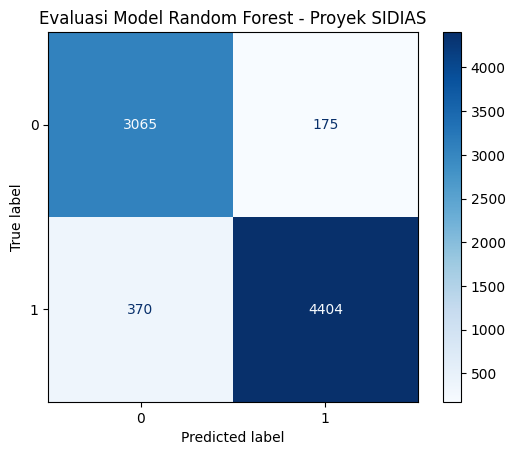

In [23]:
# Melakukan prediksi pada data pengujian yang belum pernah dilihat model
y_pred = model_rf.predict(X_test)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

# Menampilkan Confusion Matrix secara Visual
print("\n=== CONFUSION MATRIX ===")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Evaluasi Model Random Forest - Proyek SIDIAS')
plt.show()

## Menyimpan Model (.pkl) untuk Aplikasi Web Streamlit

In [25]:

os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)

# Menyimpan file model biner agar nanti bisa di-load di app.py Streamlit
model_path = os.path.join(MODEL_OUTPUT_DIR, 'random_forest_stunting_model.pkl')
joblib.dump(model_rf, model_path)

print(f"🏁 SUCCESS: Model berhasil disimpan di folder absolut: \n   {model_path}")
print("🚀 Model ini siap diintegrasikan ke backend!")

🏁 SUCCESS: Model berhasil disimpan di folder absolut: 
   ../models\random_forest_stunting_model.pkl
🚀 Model ini siap diintegrasikan ke backend!
